## LTAN
The goal of the notebook is to plot the Local Time of Ascending Node for the simulation of all 5 years.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import get_sun
import astropy.units as u

In [2]:
time_file = "../../results/data/times.npy"
alt_file = "../../results/data/altitude.npy"
AOP_file = "../../results/data/AOP.npy"
ECC_file = "../../results/data/ECC.npy"
INC_file = "../../results/data/INC.npy"
RAAN_file = "../../results/data/RAAN.npy"

with open(time_file, "rb") as f:
    times = np.load(f)
with open(alt_file, "rb") as f:
    alt = np.load(f)
with open(AOP_file, "rb") as f:
    AOP = np.load(f)
with open(ECC_file, "rb") as f:
    ECC = np.load(f)
with open(INC_file, "rb") as f:
    INC = np.load(f)
with open(RAAN_file, "rb") as f:
    RAAN = np.load(f)

#the starttime  should be 2028-05-01 09:00:00, but time is in seconds starting from 0
start = Time("2028-05-01 09:00:00", scale="utc")
time= Time(start + TimeDelta(times, format='sec'))

raan_deg = RAAN * (180.0 / np.pi)  # Convert to degrees

/home/fabian/miniconda3/envs/digital_twin_env/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 37984 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [3]:
sun = get_sun(time)
sun_ra_deg = sun.ra.to(u.deg).value  # in degrees

# LTAN formula
ltan_hours = 12 + (raan_deg - sun_ra_deg) / 15.0

# Normalize 0–24 hours
ltan_hours = np.mod(ltan_hours, 24)
ltan_hours = ltan_hours - ltan_hours[0]

/home/fabian/miniconda3/envs/digital_twin_env/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 37984 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


/home/fabian/miniconda3/envs/digital_twin_env/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 37984 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


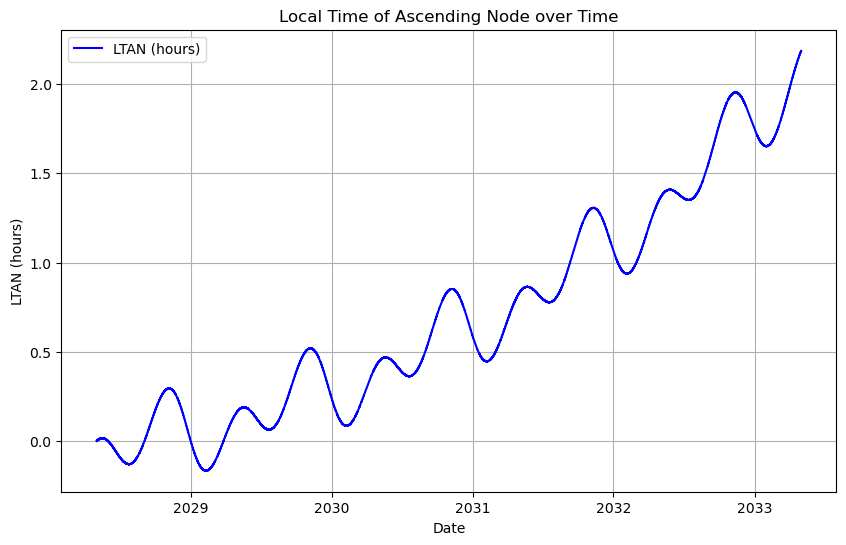

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(time.to_datetime(), ltan_hours, label='LTAN (hours)', color='blue')
plt.xlabel('Date')
plt.ylabel('LTAN (hours)')
plt.title('Local Time of Ascending Node over Time')
plt.grid(True)
plt.legend()
plt.savefig('../../results/figures/LTAN_over_time.png')
plt.show()